<a href="https://colab.research.google.com/github/PHAMVANTU467/DEEP-LEARNING/blob/main/ANN_Buoi03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bước 1: Khai báo thư viện và Cấu hình hệ thống

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


# Bước 2: Tải bộ dữ liệu Fashion MNIST

In [ ]:
# Load the Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()

# Display the shapes of the datasets
print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


# Bước 3: Tiền xử lý và Chuẩn hóa dữ liệu

In [ ]:
# Normalize pixel values
train_images = train_images / 255.0
test_images = test_images / 255.0

# Define class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Data normalized and class names defined.")

Data normalized and class names defined.


# Bước 4: Xây dựng cấu trúc mô hình ANN

In [ ]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

# Bước 5: Huấn luyện mô hình (Training)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8160 - loss: 0.5243 - val_accuracy: 0.8533 - val_loss: 0.4221
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8600 - loss: 0.3902 - val_accuracy: 0.8669 - val_loss: 0.3752
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8737 - loss: 0.3465 - val_accuracy: 0.8759 - val_loss: 0.3468
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8831 - loss: 0.3212 - val_accuracy: 0.8816 - val_loss: 0.3355
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8911 - loss: 0.2992 - val_accuracy: 0.8776 - val_loss: 0.3396
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8957 - loss: 0.2867 - val_accuracy: 0.8806 - val_loss: 0.3409
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8978 - loss: 0.2720 - val_accuracy: 0.8851 - val_loss: 0.3291
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9036 - loss: 0.2605 -

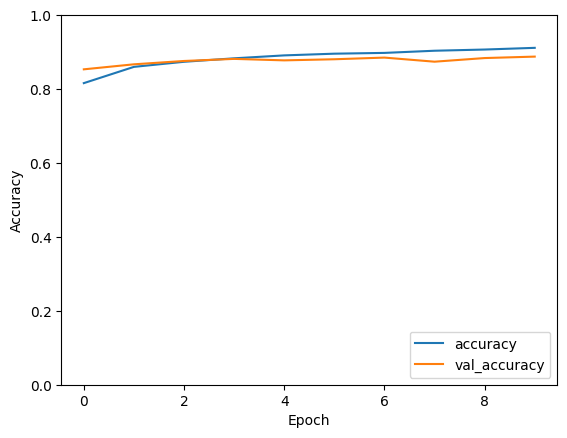

In [ ]:
history = model.fit(train_images, train_labels, epochs=10, validation_split=0.2)

# Plot training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

# Bước 6: Đánh giá mô hình trên tập dữ liệu kiểm tra

In [ ]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nTest accuracy: {test_acc*100:.2f}%')

313/313 - 1s - 2ms/step - accuracy: 0.8808 - loss: 0.3490

Test accuracy: 88.08%


# Bước 7: Dự đoán và Trực quan hóa kết quả

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


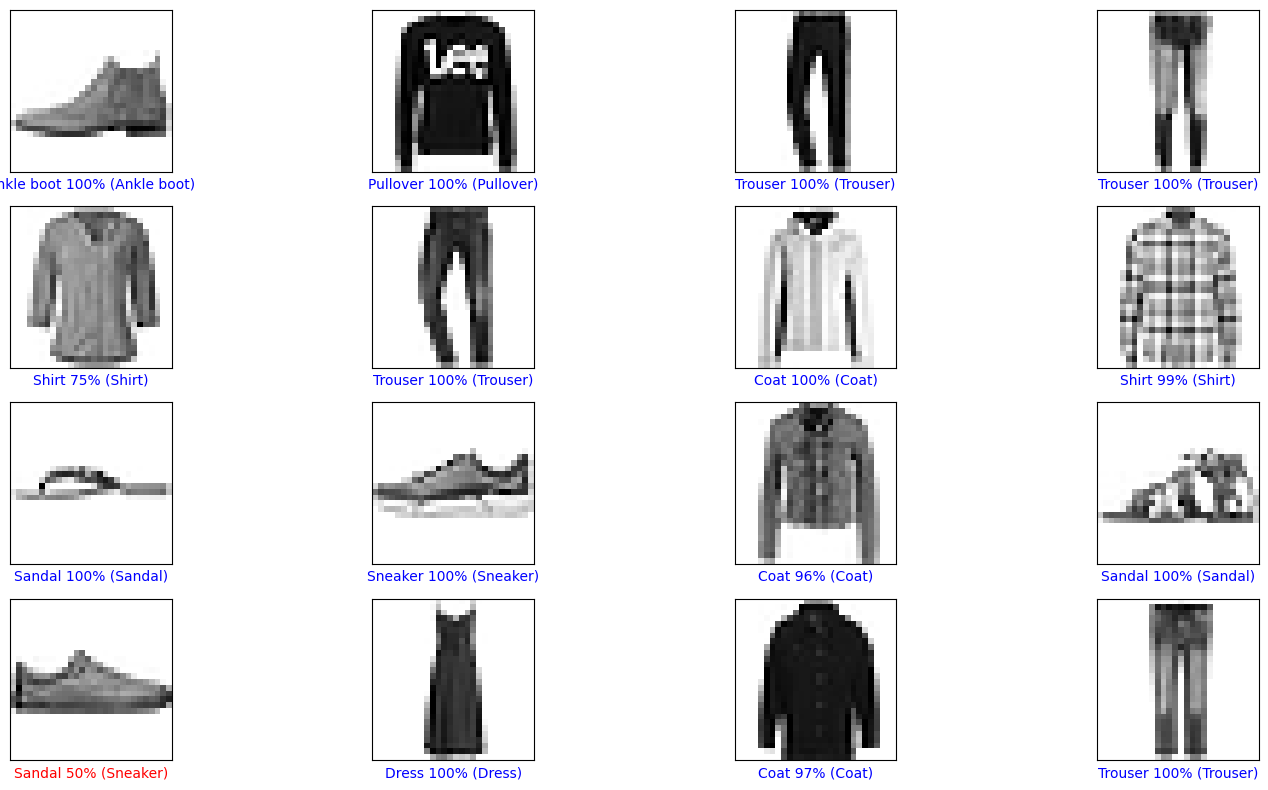

In [ ]:
predictions = model.predict(test_images)

def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel(f"{class_names[predicted_label]} {100*np.max(predictions_array):2.0f}% ({class_names[true_label]})", color=color)

num_rows = 4
num_cols = 4
num_images = num_rows * num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, num_cols, i+1)
    plot_image(i, predictions[i], test_labels, test_images)
plt.tight_layout()
plt.show()

# Bước 8: BUILD MODEL CNN

In [ ]:
# Chuẩn bị dữ liệu cho CNN (cần thêm chiều kênh màu - channel)
train_images_cnn = train_images.reshape((60000, 28, 28, 1))
test_images_cnn = test_images.reshape((10000, 28, 28, 1))

# Xây dựng mô hình CNN
cnn_model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Huấn luyện CNN
print("Đang huấn luyện mô hình CNN...")
cnn_history = cnn_model.fit(train_images_cnn, train_labels, epochs=5, validation_split=0.2, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Đang huấn luyện mô hình CNN...
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.8225 - loss: 0.4897 - val_accuracy: 0.8739 - val_loss: 0.3578
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.8811 - loss: 0.3290 - val_accuracy: 0.8874 - val_loss: 0.3096
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.8961 - loss: 0.2814 - val_accuracy: 0.8978 - val_loss: 0.2796
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9083 - loss: 0.2511 - val_accuracy: 0.9043 - val_loss: 0.2670
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.9170 - loss: 0.2232 - val_accuracy: 0.9090 - val_loss: 0.2538


# Bước 9: So sánh ANN và CNN

In [ ]:
# Đánh giá CNN
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(test_images_cnn, test_labels, verbose=0)

# Hiển thị bảng so sánh
import pandas as pd
comparison_data = {
    "Mô hình": ["ANN (Simple)", "CNN (Deep)"],
    "Độ chính xác (Test Accuracy)": [f"{test_acc*100:.2f}%", f"{cnn_test_acc*100:.2f}%"],
    "Độ mất mát (Test Loss)": [f"{test_loss:.4f}", f"{cnn_test_loss:.4f}"]
}

df_compare = pd.DataFrame(comparison_data)
display(df_compare)

,Mô hình,Độ chính xác (Test Accuracy),Độ mất mát (Test Loss)
0,ANN (Simple),88.08%,0.3490
1,CNN (Deep),90.51%,0.2634


### Bước 10: Kết quả dự đoán của CNN

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


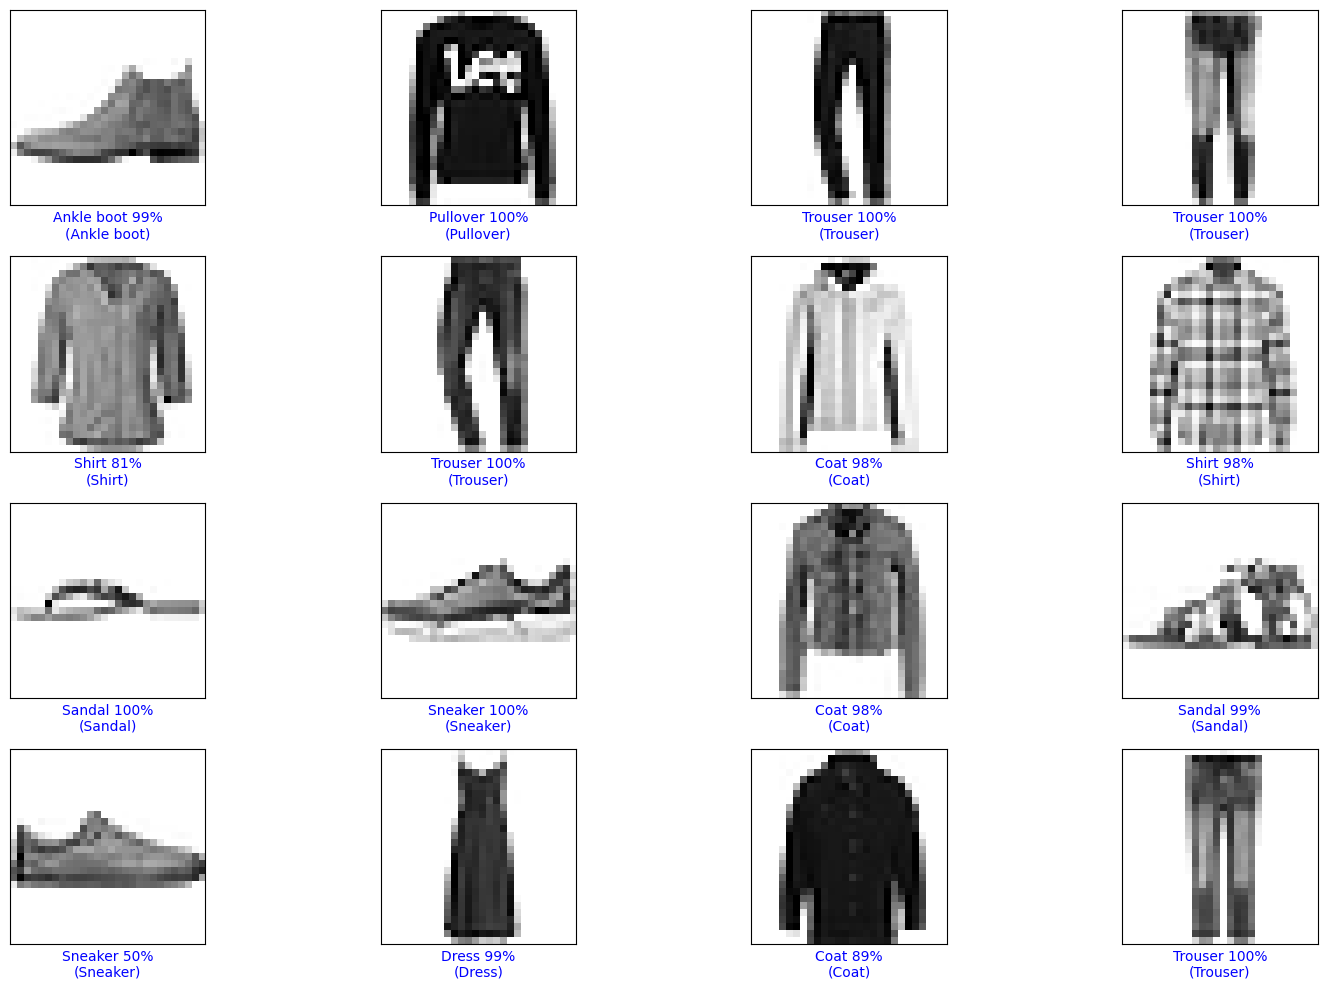

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Lấy dự đoán từ mô hình CNN
cnn_predictions = cnn_model.predict(test_images_cnn)

# Hàm vẽ ảnh dự đoán
def plot_image_cnn(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img.reshape(28,28), cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel(f"{class_names[predicted_label]} {100*np.max(predictions_array):2.0f}%\n({class_names[true_label]})", color=color)

# Hiển thị lưới 6x6 hình ảnh
num_rows = 4
num_cols = 4
num_images = num_rows * num_cols
plt.figure(figsize=(2*2*num_cols, 2.5*num_rows))

for i in range(num_images):
    plt.subplot(num_rows, num_cols, i+1)
    plot_image_cnn(i, cnn_predictions[i], test_labels, test_images_cnn)

plt.tight_layout()
plt.show()